# Wiskunde II - Portfolio: CO₂-Uitstoot en Mobiliteitsgedrag

## Groep 7
**Studenten:** Baset Paiman (24071005) | Sharina Nasrullah (25103083) | Shelby Gibbs (18005055)

---

## Samenvatting

Dit portfolio onderzoekt de relatie tussen persoonlijke kenmerken, mobiliteitskeuzes en CO₂-uitstoot. Met behulp van beschrijvende statistiek, correlatieanalyse, kansberekening, hypothesetoetsing en machine learning zoeken we antwoord op twee centrale vragen:

1. **Welke factoren verklaren verschillen in jaarlijkse CO₂-uitstoot tussen burgers?**
2. **Kunnen we individuele uitstoot nauwkeurig voorspellen op basis van sociaaldemografische kenmerken en mobiliteitsgedrag?**

Het onderzoek is gebaseerd op data van 1500 burgers met informatie over hun sociaaldemografische kenmerken, woonlocatie, mobiliteitskeuzes en jaarlijkse CO₂-uitstoot.

---

# 1. Setup en Voorbereiding

## 1.1 Import Libraries

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, norm, ttest_ind, mannwhitneyu, f_oneway
from scipy.stats import pearsonr, spearmanr
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# Set style for visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 1.2 Data Inladen en Initiële Verkenning

In [25]:
df = pd.read_excel('https://github.com/Sharina-nas/wiskunde-portfolio/raw/main/Mobiliteitsdata.xlsx')

print(f"Dataset vorm: {df.shape} (rijen, kolommen)")
print(f"\nKolomnamen:")
print(df.columns.tolist())
print(f"\nEerste 5 rijen:")
display(df.head())

Dataset vorm: (1500, 22) (rijen, kolommen)

Kolomnamen:
['persoon_ID', 'geslacht', 'leeftijd', 'gewicht_KG', 'burgerlijke_staat', 'jaarsalaris_eu', 'huishouden_grootte', 'stad', 'provincie', 'opleiding_niveau', 'autobezit', 'fietsbezit', 'elektrisch_auto', 'km_auto_per_jaar', 'km_fiets_per_jaar', 'km_ov_per_jaar', 'km_vliegtuig_per_jaar', 'dagen_thuiswerken_per_week_pro_rato', 'dagen_kantoorwerken_per_week_pro_rato', 'dagen_in_buitenland_per_jaar', 'gebruik_carsharing', 'co2_uitstoot_per_jaar_KG']

Eerste 5 rijen:


,persoon_ID,geslacht,leeftijd,gewicht_KG,burgerlijke_staat,jaarsalaris_eu,huishouden_grootte,stad,provincie,opleiding_niveau,...,elektrisch_auto,km_auto_per_jaar,km_fiets_per_jaar,km_ov_per_jaar,km_vliegtuig_per_jaar,dagen_thuiswerken_per_week_pro_rato,dagen_kantoorwerken_per_week_pro_rato,dagen_in_buitenland_per_jaar,gebruik_carsharing,co2_uitstoot_per_jaar_KG
0,811069,man,50,52.66,weduwe/weduwnaar,48003.64,5,Almere,Flevoland,MBO,...,nee,13266.05,2040.54,3227.95,480.71,4,1,20,Nooit,7591.93
1,246882,vrouw,65,64.58,samenwonend,55208.63,2,Leeuwarden,Overijssel,WO,...,nee,15229.89,0.00,2298.96,1423.34,5,0,7,Heel soms,8742.25
2,978385,man,49,90.87,samenwonend,29533.78,2,Tilburg,Utrecht,HBO,...,ja,19853.24,1540.46,4504.21,632.48,4,1,2,Altijd,4513.56
3,120468,man,34,80.43,gehuwd,44453.27,2,Maastricht,Utrecht,HBO,...,nee,9935.50,1825.92,4407.56,1266.84,3,2,21,Heel soms,6904.41
4,637034,man,60,72.28,ongehuwd,56497.64,2,Leiden,Gelderland,MBO,...,ja,16266.67,1851.07,1936.12,1676.00,0,5,0,Nooit,4420.80


---

# 2. Beschrijvende Statistiek en Data Validatie

## 2.1 Meetniveaus van Variabelen

**Vraag 1:** Elk meetniveau vereist andere statistische behandeling:

- **Nominaal** (geen natuurlijke volgorde): geslacht, burgerlijke_staat, stad, provincie, autobezit, fietsbezit, elektrisch_auto
- **Ordinaal** (natuurlijke volgorde): opleiding_niveau, gebruik_carsharing
- **Ratio** (nulpunt betekenis): leeftijd, gewicht_KG, jaarsalaris_eu, huishouden_grootte, en alle kilometer/dag-variabelen, co2_uitstoot_per_jaar_KG

**Vraag 2:** Het is nodig om het meetniveau vooraf te bepalen omdat:
- Dit bepaalt welke statistische maten relevant zijn (gemiddelde bij ratio, modus/frequentie bij nominaal)
- Dit bepaalt welke toetsen we mogen gebruiken (parametrisch vs non-parametrisch)
- Dit bepaalt hoe we variabelen transformeren voor machine learning

## 2.2 Relevante Beschrijvende Statistieken

### Ratio-variabelen: Descriptieve Statistieken

Voor ratio-variabelen berekenen we: gemiddelde, mediaan, standaarddeviatie, minimum, maximum en kwartielen (Q1, Q3).

In [26]:
ratio_variabelen= [
    'leeftijd',
    'gewicht_KG', 
    'jaarsalaris_eu', 
    'huishouden_grootte', 
    'km_auto_per_jaar', 
    'km_fiets_per_jaar',
    'km_ov_per_jaar',
    'km_vliegtuig_per_jaar',
    'dagen_thuiswerken_per_week_pro_rato',
    'dagen_kantoorwerken_per_week_pro_rato',
    'dagen_in_buitenland_per_jaar',
    'co2_uitstoot_per_jaar_KG'] 

display(df[ratio_variabelen].describe())

# dus voor ratio variabelen zijn de relevante statistieken: 
# gemiddelde, mediaan, standaarddeviatie, minimum, maximum en kwartielen.

,leeftijd,gewicht_KG,jaarsalaris_eu,huishouden_grootte,km_auto_per_jaar,km_fiets_per_jaar,km_ov_per_jaar,km_vliegtuig_per_jaar,dagen_thuiswerken_per_week_pro_rato,dagen_kantoorwerken_per_week_pro_rato,dagen_in_buitenland_per_jaar,co2_uitstoot_per_jaar_KG
count,1500.000000,1500.00000,1499.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1493.000000
mean,47.989333,75.14630,40092.551094,3.032000,8597.262393,1794.180353,2942.222840,1072.277327,2.532667,2.467333,14.485333,4912.341875
std,18.134915,14.79674,14986.839768,1.411017,7021.428530,753.991154,1531.377214,748.651072,1.671365,1.671365,8.700819,3422.902397
min,0.000000,0.00000,-8505.150000,1.000000,-6506.630000,0.000000,-2264.780000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,32.000000,65.63500,30008.920000,2.000000,0.000000,1503.420000,1950.682500,471.540000,1.000000,1.000000,7.000000,1469.450000
50%,47.000000,75.79000,40503.080000,3.000000,9356.380000,1910.005000,2987.030000,1052.140000,3.000000,2.000000,15.000000,4677.280000
75%,64.000000,84.93500,50281.165000,4.000000,13842.732500,2286.180000,3991.537500,1588.555000,4.000000,4.000000,22.000000,7481.550000
max,79.000000,117.76000,93826.850000,5.000000,34618.870000,3672.700000,8018.060000,3808.200000,5.000000,5.000000,29.000000,18098.440000


### Categorische Variabelen: Frequenties, Percentages en Modus

Voor nominale variabelen berekenen we: frequenties, percentages en modus.
Voor ordinale variabelen voegen we mediaan toe aan deze statistieken.

In [10]:
categorie_variabelen= [
    'geslacht',
    'burgerlijke_staat',
    'stad',
    'provincie',
    'opleiding_niveau',
    'autobezit',
    'fietsbezit',
    'elektrisch_auto',
    'gebruik_carsharing'
]

for kolom in categorie_variabelen:
    print(f"\n==== {kolom} ====")
    print(df[kolom].value_counts())


## voor nominale variabelen zijn de relevante statistieken:
# frequenties, percentages en modus. 

# voor ordinale variabelen zijn de relevante statistieken:
# frequenties, percentages, modus en mediaan.


==== geslacht ====
geslacht
vrouw     778
man       720
anders      2
Name: count, dtype: int64

==== burgerlijke_staat ====
burgerlijke_staat
gehuwd              312
gescheiden          310
ongehuwd            310
weduwe/weduwnaar    287
samenwonend         281
Name: count, dtype: int64

==== stad ====
stad
Breda         72
Amsterdam     72
Enschede      67
Nijmegen      67
Utrecht       67
Venlo         66
Tilburg       62
Den Bosch     62
Leeuwarden    62
Middelburg    62
Leiden        61
Maastricht    61
Groningen     60
Zutphen       60
Eindhoven     60
Amersfoort    59
Rotterdam     57
Zwolle        56
Delft         54
Haarlem       54
Apeldoorn     54
Arnhem        53
Hoofddorp     52
Assen         51
Almere        48
Name: count, dtype: int64

==== provincie ====
provincie
Groningen        157
Flevoland        142
Limburg          140
Zeeland          130
Noord-Holland    125
Drenthe          125
Overijssel       124
Utrecht          118
Friesland        118
Gelderland       1

## 2.3 Data Kwaliteit: Behandeling van Ontbrekende en Extreme Waarden

**Vraag 3:** Voor deze dataset hebben we:
- Alle rijen met ontbrekende waarden verwijderd
- Negatieve waarden verwijderd uit km_auto_per_jaar en km_ov_per_jaar (onmogelijk)
- Personen met gewicht ≤ 0 kg verwijderd (medisch onmogelijk)
- Personen met leeftijd ≤ 0 jaar verwijderd
- Personen met gewicht < 30 kg verwijderd (atypisch voor volwassenen)

Volgende stap: aanvullende validatie op plausibiliteit.

In [27]:
print("=== CATEGORISCHE VARIABELEN: FREQUENTIES EN PERCENTAGES ===\n")

categorie_variabelen = [
    'geslacht',
    'burgerlijke_staat',
    'stad',
    'provincie',
    'opleiding_niveau',
    'autobezit',
    'fietsbezit',
    'elektrisch_auto',
    'gebruik_carsharing'
]

for kolom in categorie_variabelen:
    print(f"\n{'='*50}")
    print(f"{kolom.upper()}")
    print(f"{'='*50}")
    print("\nFrequenties:")
    print(df[kolom].value_counts())
    print("\nPercentages:")
    print(df[kolom].value_counts(normalize=True) * 100)
    print(f"Modus: {df[kolom].mode()[0]}")

=== CATEGORISCHE VARIABELEN: FREQUENTIES EN PERCENTAGES ===


GESLACHT

Frequenties:
geslacht
vrouw     778
man       720
anders      2
Name: count, dtype: int64

Percentages:
geslacht
vrouw     51.866667
man       48.000000
anders     0.133333
Name: proportion, dtype: float64
Modus: vrouw

BURGERLIJKE_STAAT

Frequenties:
burgerlijke_staat
gehuwd              312
gescheiden          310
ongehuwd            310
weduwe/weduwnaar    287
samenwonend         281
Name: count, dtype: int64

Percentages:
burgerlijke_staat
gehuwd              20.800000
gescheiden          20.666667
ongehuwd            20.666667
weduwe/weduwnaar    19.133333
samenwonend         18.733333
Name: proportion, dtype: float64
Modus: gehuwd

STAD

Frequenties:
stad
Breda         72
Amsterdam     72
Enschede      67
Nijmegen      67
Utrecht       67
Venlo         66
Tilburg       62
Den Bosch     62
Leeuwarden    62
Middelburg    62
Leiden        61
Maastricht    61
Groningen     60
Zutphen       60
Eindhoven     60
Ame

### Stap 1: Ontbrekende Waarden Verwijderen

In [28]:
print("Ontbrekende waarden per kolom:")
missing = df.isnull().sum()
print(missing[missing > 0])

print(f"\nTotaal rijen voor data cleaning: {len(df)}")
df = df.dropna()
print(f"Totaal rijen na verwijdering ontbrekende waarden: {len(df)}")

# Definieer ratio variabelen voor vervolganalyse
ratio_variabelen = [
    'leeftijd',
    'gewicht_KG', 
    'jaarsalaris_eu', 
    'huishouden_grootte', 
    'km_auto_per_jaar', 
    'km_fiets_per_jaar',
    'km_ov_per_jaar',
    'km_vliegtuig_per_jaar',
    'dagen_thuiswerken_per_week_pro_rato',
    'dagen_kantoorwerken_per_week_pro_rato',
    'dagen_in_buitenland_per_jaar',
    'co2_uitstoot_per_jaar_KG'
]

Ontbrekende waarden per kolom:
jaarsalaris_eu              1
stad                        1
opleiding_niveau            1
autobezit                   1
co2_uitstoot_per_jaar_KG    7
dtype: int64

Totaal rijen voor data cleaning: 1500
Totaal rijen na verwijdering ontbrekende waarden: 1489


Boxplots voor alle ratio-variabelen:


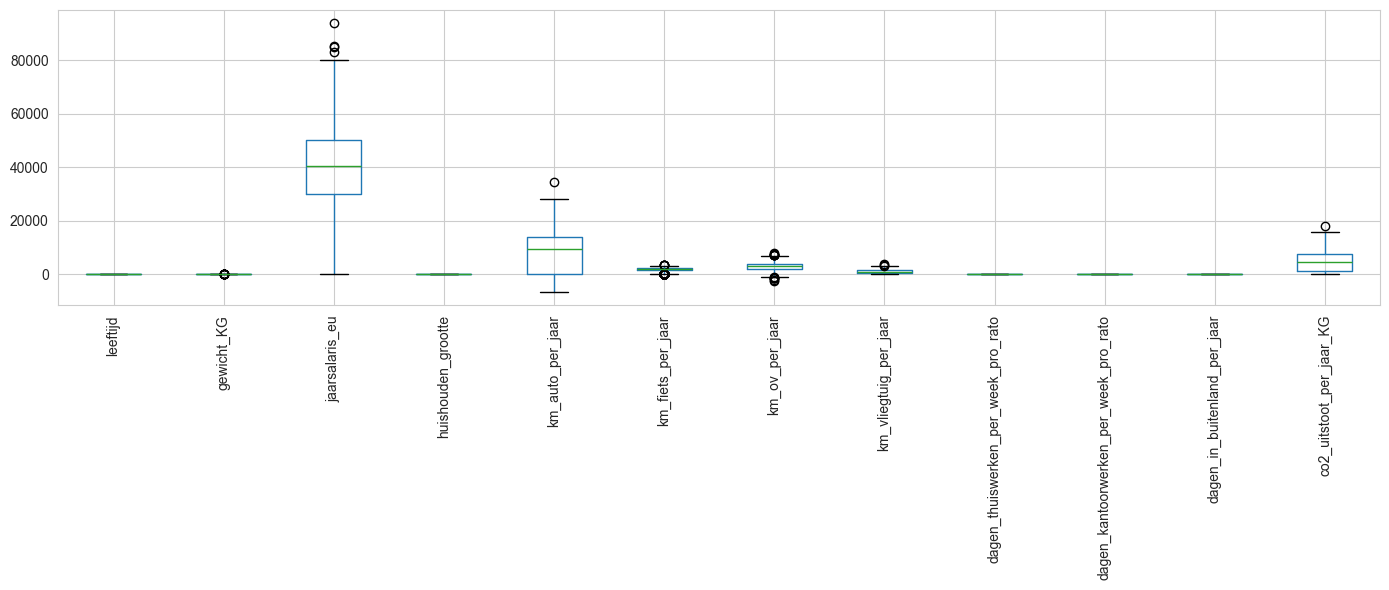


Stap 2a: Negatieve kilometer waarden verwijderen...
Rijen verwijderd: 52

Stap 2b: Onmogelijke gewicht- en leeftijdswaarden verwijderen...
Rijen verwijderd: 7

Stap 2c: Aanvullende validatie op plausibiliteit...
Rijen met implausibele waarden gevonden: 0
Rijen verwijderd: 0

Final dataset size: 1430 rijen

Beschrijvende statistieken na data cleaning:


,leeftijd,gewicht_KG,jaarsalaris_eu,huishouden_grootte,km_auto_per_jaar,km_fiets_per_jaar,km_ov_per_jaar,km_vliegtuig_per_jaar,dagen_thuiswerken_per_week_pro_rato,dagen_kantoorwerken_per_week_pro_rato,dagen_in_buitenland_per_jaar,co2_uitstoot_per_jaar_KG
count,1430.000000,1430.000000,1430.000000,1430.000000,1430.000000,1430.000000,1430.000000,1430.000000,1430.000000,1430.000000,1430.000000,1430.000000
mean,47.826573,75.298140,40269.026119,3.031469,8709.152643,1791.338601,3047.680476,1071.124958,2.539860,2.460140,14.440559,4963.057077
std,18.058938,14.187194,14593.141861,1.412130,6986.455151,755.727661,1422.975325,748.497430,1.669139,1.669139,8.715488,3421.187357
min,18.000000,31.050000,294.110000,1.000000,0.000000,0.000000,3.060000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,32.000000,65.605000,30192.435000,2.000000,0.000000,1501.837500,2061.082500,471.352500,1.000000,1.000000,7.000000,1506.080000
50%,47.000000,75.690000,40591.530000,3.000000,9453.425000,1905.120000,3059.225000,1050.655000,3.000000,2.000000,15.000000,4713.760000
75%,64.000000,84.717500,50276.792500,4.000000,13950.467500,2276.505000,4015.300000,1583.230000,4.000000,4.000000,22.000000,7535.702500
max,79.000000,117.760000,85299.950000,5.000000,34618.870000,3672.700000,8018.060000,3808.200000,5.000000,5.000000,29.000000,18098.440000


In [29]:
# Visualiseer eerste verdeling met boxplots om outliers te identificeren
print("Boxplots voor alle ratio-variabelen:")
df[ratio_variabelen].boxplot(rot=90, figsize=(14, 6))
plt.tight_layout()
plt.show()

# Stap 2a: Verwijder negatieve kilometer waarden
print("\nStap 2a: Negatieve kilometer waarden verwijderen...")
initial_len = len(df)
df = df[df['km_auto_per_jaar'] >= 0]
df = df[df['km_ov_per_jaar'] >= 0]
print(f"Rijen verwijderd: {initial_len - len(df)}")

# Stap 2b: Verwijder onmogelijke gewicht waarden
print("\nStap 2b: Onmogelijke gewicht- en leeftijdswaarden verwijderen...")
initial_len = len(df)
df = df[df['gewicht_KG'] > 0]
df = df[df['leeftijd'] > 0]
df = df[df['gewicht_KG'] >= 30]  # volwassenen
print(f"Rijen verwijderd: {initial_len - len(df)}")

# Stap 2c: Aanvullende validatie
print("\nStap 2c: Aanvullende validatie op plausibiliteit...")
initial_len = len(df)
invalid_rows = df[
    (df['leeftijd'] > 120) |
    (df['huishouden_grootte'] < 1) |
    (df['dagen_thuiswerken_per_week_pro_rato'] > 7) |
    (df['dagen_kantoorwerken_per_week_pro_rato'] > 7) |
    (df['dagen_in_buitenland_per_jaar'] > 365)
]
print(f"Rijen met implausibele waarden gevonden: {len(invalid_rows)}")
df = df[
    (df['leeftijd'] <= 120) &
    (df['huishouden_grootte'] >= 1) &
    (df['dagen_thuiswerken_per_week_pro_rato'] <= 7) &
    (df['dagen_kantoorwerken_per_week_pro_rato'] <= 7) &
    (df['dagen_in_buitenland_per_jaar'] <= 365)
]
print(f"Rijen verwijderd: {initial_len - len(df)}")

print(f"\nFinal dataset size: {len(df)} rijen")
print("\nBeschrijvende statistieken na data cleaning:")
display(df[ratio_variabelen].describe())

---

# 3. Verdelingsanalyse: Keuze Onafhankelijke Variabelen

## 3.1 Selectie van Onafhankelijke Variabelen

Voor verdere analyse kiezen we twee onafhankelijke variabelen die we verwachten CO₂-uitstoot te beïnvloeden:

1. **`km_auto_per_jaar`** - Direct transport, een van de eerste factoren die CO₂ beïnvloedt
2. **`km_vliegtuig_per_jaar`** - Vliegen heeft een zeer hoge CO₂-voetafdruk per kilometer

Deze variabelen zijn theoretisch gefundeerd omdat zij direct gerelateerd zijn aan mobiliteit en energieverbruik. We visualiseren deze twee variabelen en de target variabele `co2_uitstoot_per_jaar_KG`.

## 3.2 Distributies van Geselecteerde Variabelen

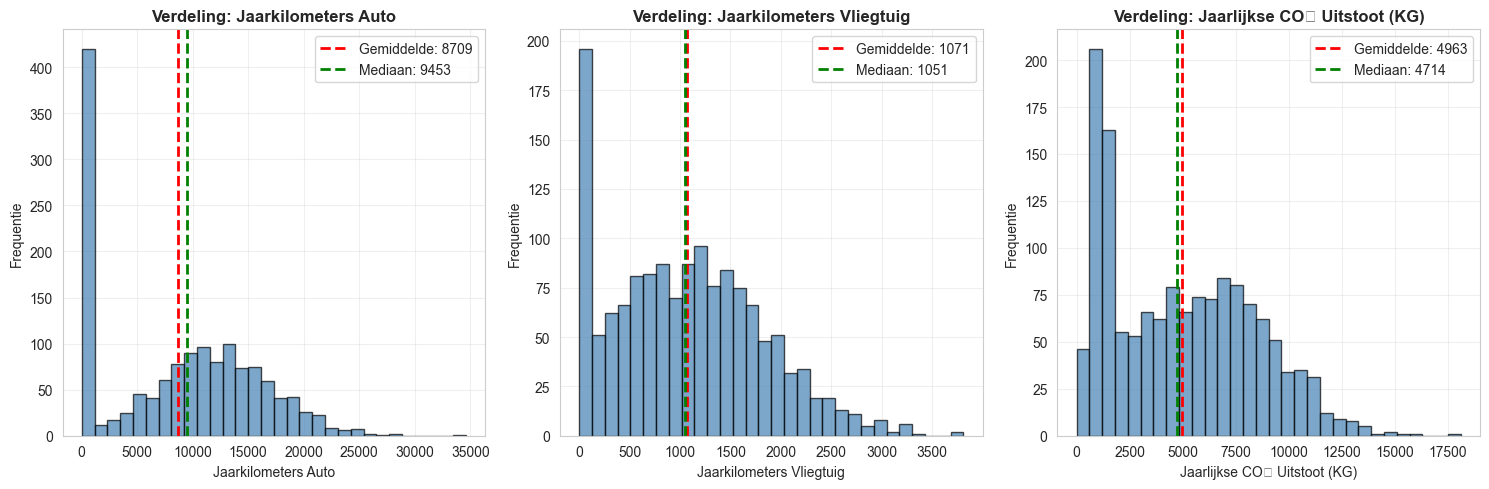


=== BESCHRIJVENDE STATISTIEKEN ===

Jaarkilometers Auto:
  Gemiddelde: 8709.15
  Mediaan: 9453.42
  Standaarddeviatie: 6986.46
  Min: 0.00
  Max: 34618.87
  Skewness: 0.15
  Kurtosis: -0.97

Jaarkilometers Vliegtuig:
  Gemiddelde: 1071.12
  Mediaan: 1050.65
  Standaarddeviatie: 748.50
  Min: 0.00
  Max: 3808.20
  Skewness: 0.42
  Kurtosis: -0.32

Jaarlijkse CO₂ Uitstoot (KG):
  Gemiddelde: 4963.06
  Mediaan: 4713.76
  Standaarddeviatie: 3421.19
  Min: 0.00
  Max: 18098.44
  Skewness: 0.42
  Kurtosis: -0.72



In [30]:
# Visualiseer de verdeling van de drie variabelen
variables = {
    'km_auto_per_jaar': 'Jaarkilometers Auto',
    'km_vliegtuig_per_jaar': 'Jaarkilometers Vliegtuig',
    'co2_uitstoot_per_jaar_KG': 'Jaarlijkse CO₂ Uitstoot (KG)'
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, (var, label) in enumerate(variables.items()):
    ax = axes[idx]
    ax.hist(df[var], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    ax.set_title(f'Verdeling: {label}', fontsize=12, fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('Frequentie')
    ax.grid(True, alpha=0.3)
    
    # Add statistics to plot
    mean_val = df[var].mean()
    median_val = df[var].median()
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Gemiddelde: {mean_val:.0f}')
    ax.axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Mediaan: {median_val:.0f}')
    ax.legend()

plt.tight_layout()
plt.show()

# Print descriptive statistics
print("\n=== BESCHRIJVENDE STATISTIEKEN ===\n")
for var, label in variables.items():
    print(f"{label}:")
    print(f"  Gemiddelde: {df[var].mean():.2f}")
    print(f"  Mediaan: {df[var].median():.2f}")
    print(f"  Standaarddeviatie: {df[var].std():.2f}")
    print(f"  Min: {df[var].min():.2f}")
    print(f"  Max: {df[var].max():.2f}")
    print(f"  Skewness: {df[var].skew():.2f}")
    print(f"  Kurtosis: {df[var].kurtosis():.2f}\n")

## 3.3 Normaliteitstesten

**Vraag 4:** Beschrijving van de verdelingen met statistische termen (zie hierboven), inclusief scheefheid (skewness) en spitsvoetigheid (kurtosis).

We toetsen nu of deze verdelingen normaal verdeeld zijn met de Shapiro-Wilk test. De nulhypothese is dat de verdeling normaal is (p > 0.05 suggereert normaliteit).

In [31]:
# Shapiro-Wilk test voor normaliteit
print("=== SHAPIRO-WILK NORMALITEIT TEST ===\n")

normality_results = {}
for var, label in variables.items():
    stat, p_value = shapiro(df[var])
    normality_results[var] = {'statistic': stat, 'p_value': p_value}
    
    print(f"{label}:")
    print(f"  Test statistic: {stat:.4f}")
    print(f"  P-waarde: {p_value:.6f}")
    if p_value > 0.05:
        print(f"  Conclusie: NORMAAL VERDEELD (p > 0.05)")
    else:
        print(f"  Conclusie: NIET NORMAAL VERDEELD (p ≤ 0.05)")
    print()

# **Vraag 5:** Conclusie normaliteit
print("\n=== CONCLUSIE (VRAAG 5) ===")
print("Op basis van de Shapiro-Wilk tests:")
non_normal = [v for v, res in normality_results.items() if res['p_value'] <= 0.05]
print(f"Variabelen die NIET normaal zijn verdeeld: {non_normal}")
print("\nDit heeft implicaties voor de keuze van statistische toetsen later in het onderzoek.")

=== SHAPIRO-WILK NORMALITEIT TEST ===

Jaarkilometers Auto:
  Test statistic: 0.9142
  P-waarde: 0.000000
  Conclusie: NIET NORMAAL VERDEELD (p ≤ 0.05)

Jaarkilometers Vliegtuig:
  Test statistic: 0.9653
  P-waarde: 0.000000
  Conclusie: NIET NORMAAL VERDEELD (p ≤ 0.05)

Jaarlijkse CO₂ Uitstoot (KG):
  Test statistic: 0.9411
  P-waarde: 0.000000
  Conclusie: NIET NORMAAL VERDEELD (p ≤ 0.05)


=== CONCLUSIE (VRAAG 5) ===
Op basis van de Shapiro-Wilk tests:
Variabelen die NIET normaal zijn verdeeld: ['km_auto_per_jaar', 'km_vliegtuig_per_jaar', 'co2_uitstoot_per_jaar_KG']

Dit heeft implicaties voor de keuze van statistische toetsen later in het onderzoek.


---

# 4. Data Voorbereiding voor Machine Learning

## 4.1 Transformatie van Variabelen

**Vraag 6:** Voor machine learning moeten variabelen van verschillende meetniveaus getransformeerd worden:

- **Nominale variabelen**: One-hot encoding (dummy variabelen) → binaire kolommen per categorie
- **Ordinale variabelen**: Label encoding → numerieke waarden die volgorde weergeven (1, 2, 3, ...)
- **Ratio variabelen**: Kunnen direct gebruikt worden, soms standaardisering/normalisatie

We maken een kopie van de originele data (`df_ml`) om transformaties toe te passen.

## 4.2 Implementatie Transformatie

In [32]:
# Stap 1: Maak kopie van originele data
df_ml = df.copy()

print("Stap 1: One-hot encoding van nominale variabelen\n")

nominale_variabelen = [
    'geslacht',
    'burgerlijke_staat',
    'stad',
    'provincie',
    'autobezit',
    'fietsbezit',
    'elektrisch_auto'
]

print(f"Voor transformatie: {df_ml.shape[1]} kolommen")
df_ml = pd.get_dummies(df_ml, columns=nominale_variabelen, drop_first=True)
print(f"Na transformatie: {df_ml.shape[1]} kolommen\n")

print("Nieuwe kolommen na one-hot encoding:")
new_cols = [col for col in df_ml.columns if col not in df.columns]
print(new_cols[:10], "...")  # Show first 10

Stap 1: One-hot encoding van nominale variabelen

Voor transformatie: 22 kolommen
Na transformatie: 59 kolommen

Nieuwe kolommen na one-hot encoding:
['geslacht_man', 'geslacht_vrouw', 'burgerlijke_staat_gescheiden', 'burgerlijke_staat_ongehuwd', 'burgerlijke_staat_samenwonend', 'burgerlijke_staat_weduwe/weduwnaar', 'stad_Amersfoort', 'stad_Amsterdam', 'stad_Apeldoorn', 'stad_Arnhem'] ...


In [33]:
print("Stap 2: Label encoding van ordinale variabelen\n")

# Controleer unieke waarden
print("Unieke waarden ordinale variabelen:")
print(f"\nopleiding_niveau: {df_ml['opleiding_niveau'].unique()}")
print(f"gebruik_carsharing: {df_ml['gebruik_carsharing'].unique()}")

Stap 2: Label encoding van ordinale variabelen

Unieke waarden ordinale variabelen:

opleiding_niveau: ['MBO' 'WO' 'HBO']
gebruik_carsharing: ['Nooit' 'Heel soms' 'Altijd' 'Vaak' 'Soms']


In [34]:
# Map ordinale waarden naar numerieke volgorde
opleiding_mapping = {'MBO': 1, 'HBO': 2, 'WO': 3}
carsharing_mapping = {'Nooit': 1, 'Heel soms': 2, 'Soms': 3, 'Vaak': 4, 'Altijd': 5}

df_ml['opleiding_niveau'] = df_ml['opleiding_niveau'].map(opleiding_mapping)
df_ml['gebruik_carsharing'] = df_ml['gebruik_carsharing'].map(carsharing_mapping)

print("\nOrdinal encoding toegepast:")
print(f"  opleiding_niveau: MBO=1, HBO=2, WO=3")
print(f"  gebruik_carsharing: Nooit=1, Heel soms=2, Soms=3, Vaak=4, Altijd=5")

print("\nDataset klaar voor machine learning!")
print(f"Vorm: {df_ml.shape}")
print(f"\nData types:")
print(df_ml.dtypes.value_counts())


Ordinal encoding toegepast:
  opleiding_niveau: MBO=1, HBO=2, WO=3
  gebruik_carsharing: Nooit=1, Heel soms=2, Soms=3, Vaak=4, Altijd=5

Dataset klaar voor machine learning!
Vorm: (1430, 59)

Data types:
bool       44
int64       8
float64     7
Name: count, dtype: int64


---

# 5. Correlatieanalyse: Relaties tussen Variabelen

## 5.1 Correlatiematrix Visualisatie

**Vraag 7 & 8:** We onderzoeken relaties tussen alle variabelen met twee methoden:
- **Pearson correlatie**: voor continue, normaal verdeelde variabelen
- **Spearman correlatie**: voor niet-normale of ordinale data (rank-based)

=== PEARSON CORRELATIE ===



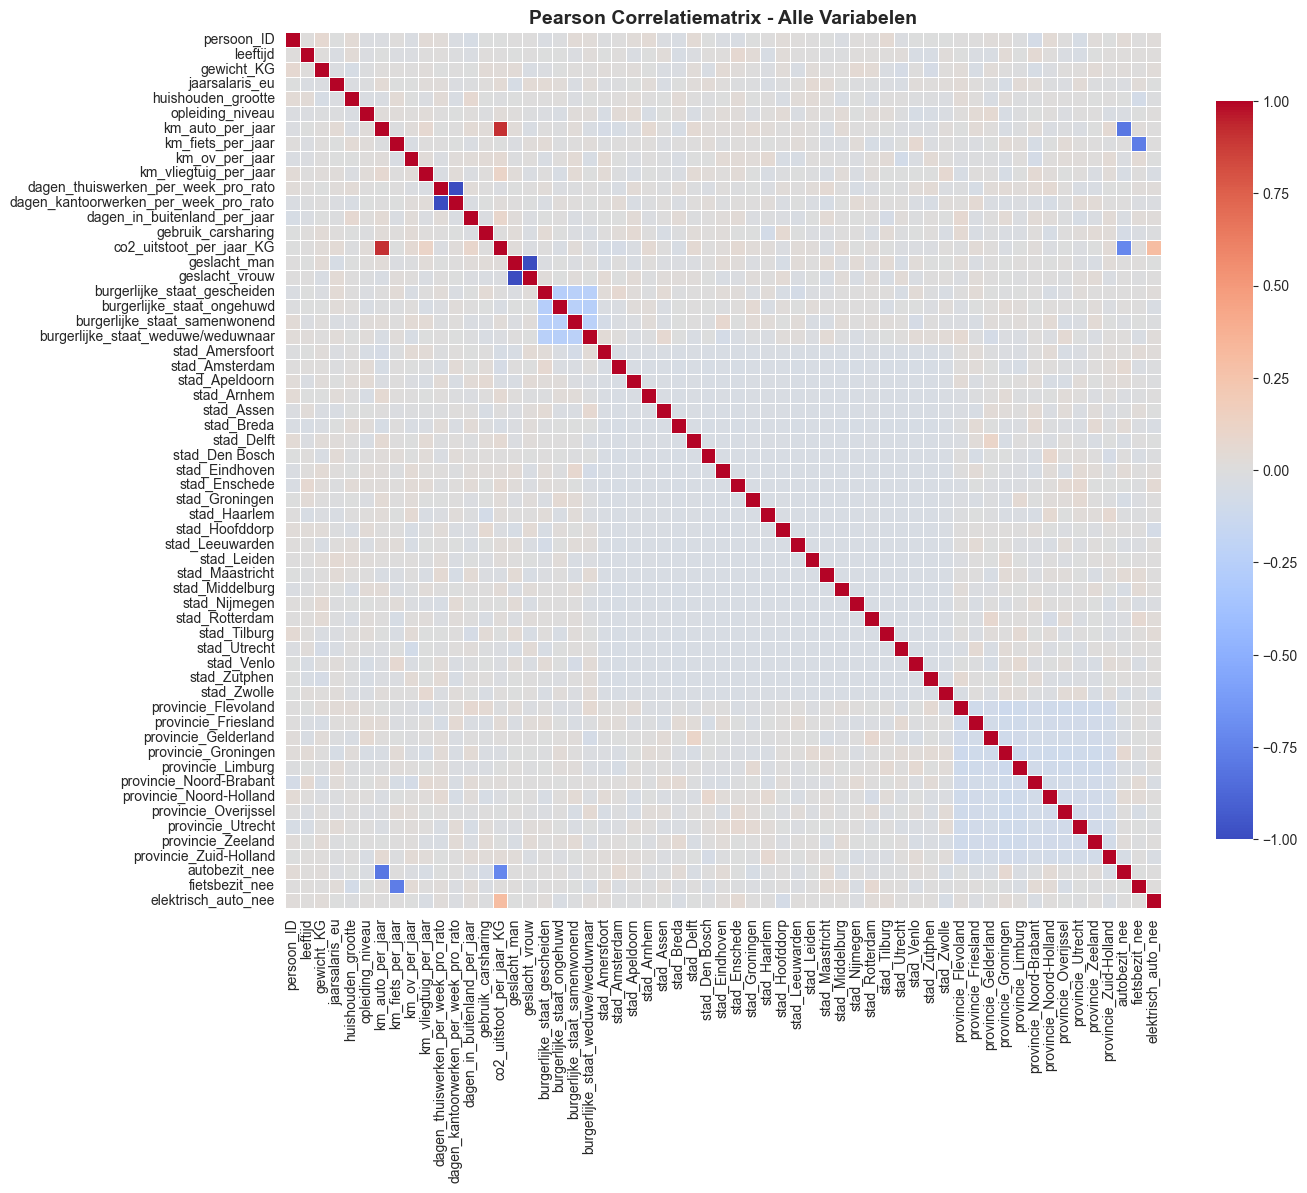


=== VARIABELEN MET STERKSTE CORRELATIE MET CO₂-UITSTOOT ===

co2_uitstoot_per_jaar_KG        1.000000
km_auto_per_jaar                0.912832
elektrisch_auto_nee             0.303029
km_vliegtuig_per_jaar           0.113468
dagen_in_buitenland_per_jaar    0.087438
km_ov_per_jaar                  0.053838
stad_Arnhem                     0.049495
stad_Delft                      0.049032
stad_Enschede                   0.048759
jaarsalaris_eu                  0.046719
provincie_Zuid-Holland          0.035321
Name: co2_uitstoot_per_jaar_KG, dtype: float64


=== SPEARMAN CORRELATIE (RANK-BASED) ===

co2_uitstoot_per_jaar_KG         1.000000
km_auto_per_jaar                 0.904631
elektrisch_auto_nee              0.278277
km_vliegtuig_per_jaar            0.140121
dagen_in_buitenland_per_jaar     0.094837
km_ov_per_jaar                   0.056691
stad_Enschede                    0.055129
stad_Arnhem                      0.046968
jaarsalaris_eu                   0.041689
stad_Delft        

In [35]:
# Bereken Pearson correlaties
print("=== PEARSON CORRELATIE ===\n")
corr_pearson = df_ml.corr(numeric_only=True, method='pearson')

# Visualiseer correlatiematrix
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr_pearson, cmap='coolwarm', center=0, annot=False, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
plt.title('Pearson Correlatiematrix - Alle Variabelen', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Focus op CO2-uitstoot correlaties
print("\n=== VARIABELEN MET STERKSTE CORRELATIE MET CO₂-UITSTOOT ===\n")
co2_corr = corr_pearson['co2_uitstoot_per_jaar_KG'].sort_values(ascending=False)
print(co2_corr.head(11))  # Top 10 + target zelf

# Bereken Spearman correlaties (rank-based, robuster voor niet-normale data)
print("\n\n=== SPEARMAN CORRELATIE (RANK-BASED) ===\n")
corr_spearman = df_ml.corr(numeric_only=True, method='spearman')
co2_corr_spearman = corr_spearman['co2_uitstoot_per_jaar_KG'].sort_values(ascending=False)
print(co2_corr_spearman.head(11))

---

# 6. Kansberekening met Standaardnormaalverdeling

## 6.1 Berekening Waarschijnlijkheid

**Vraag 9:** We berekenen de waarschijnlijkheid dat een willekeurig persoon meer dan 5000 KG CO₂ per jaar uitstoot.

### Theoretische Achtergrond

De **standaardnormaalverdeling** (ook wel normale verdeling) is één van de meest belangrijke verdelingen in de statistiek. Deze verdeling wordt gekenmerkt door:

- **Gemiddelde (μ)**: Het centrum van de verdeling
- **Standaarddeviatie (σ)**: Een maat voor spreiding (hoe ver waarden zich van het gemiddelde afwijken)
- **Vorm**: Symmetrisch, klokbel-vormig (Gaussian curve)

### Z-Score en Normalisatie

Om een waarde te vergelijken met een normale verdeling, normaliseren we deze naar een **z-score**:

$$z = \frac{X - \mu}{\sigma}$$

De z-score vertelt ons hoeveel standaarddeviaties een waarde van het gemiddelde afligt.

### Cumulatieve Verdelingsfunctie (CDF)

De CDF Φ(z) geeft de waarschijnlijkheid aan dat een willekeurig getal uit de verdeling kleiner is dan of gelijk aan z. Voor het berekenen van P(X > 5000) gebruiken we:

$$P(X > 5000) = 1 - \Phi\left(\frac{5000 - \mu}{\sigma}\right)$$

We gebruiken de normale verdeling van CO₂-uitstoot in onze dataset om deze waarschijnlijkheid te schatten.

=== KANSBEREKENING ===

CO₂-uitstoot verdeling in dataset:
  Gemiddelde (μ): 4963.06 KG
  Standaarddeviatie (σ): 3421.19 KG

Vraag: Wat is P(X > 5000 KG)?
  Z-score: (5000 - 4963.06) / 3421.19 = 0.0108
  P(X > 5000) = 1 - Φ(0.0108) = 0.495692
  Percentage: 49.57%



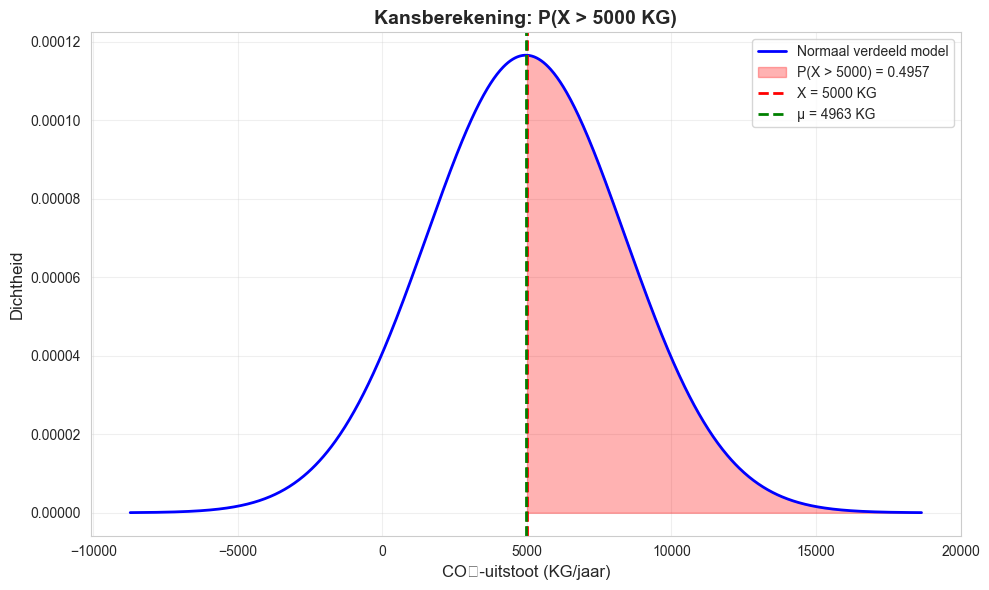

In [36]:
# Extraheer parameters van CO2-verdeling
mean_co2 = df_ml['co2_uitstoot_per_jaar_KG'].mean()
std_co2 = df_ml['co2_uitstoot_per_jaar_KG'].std()

print("=== KANSBEREKENING ===\n")
print(f"CO₂-uitstoot verdeling in dataset:")
print(f"  Gemiddelde (μ): {mean_co2:.2f} KG")
print(f"  Standaarddeviatie (σ): {std_co2:.2f} KG\n")

# Bereken kans P(X > 5000)
threshold = 5000
z_score = (threshold - mean_co2) / std_co2
prob_greater = 1 - norm.cdf(threshold, loc=mean_co2, scale=std_co2)

print(f"Vraag: Wat is P(X > {threshold} KG)?")
print(f"  Z-score: (5000 - {mean_co2:.2f}) / {std_co2:.2f} = {z_score:.4f}")
print(f"  P(X > {threshold}) = 1 - Φ({z_score:.4f}) = {prob_greater:.6f}")
print(f"  Percentage: {prob_greater*100:.2f}%\n")

# Visualiseer de verdeling met het threshold
fig, ax = plt.subplots(figsize=(10, 6))

# Plot distribution
x = np.linspace(mean_co2 - 4*std_co2, mean_co2 + 4*std_co2, 1000)
y = norm.pdf(x, mean_co2, std_co2)
ax.plot(x, y, 'b-', linewidth=2, label='Normaal verdeeld model')
ax.fill_between(x[x >= threshold], y[x >= threshold], alpha=0.3, color='red', 
                label=f'P(X > {threshold}) = {prob_greater:.4f}')
ax.axvline(threshold, color='red', linestyle='--', linewidth=2, label=f'X = {threshold} KG')
ax.axvline(mean_co2, color='green', linestyle='--', linewidth=2, label=f'μ = {mean_co2:.0f} KG')

ax.set_xlabel('CO₂-uitstoot (KG/jaar)', fontsize=12)
ax.set_ylabel('Dichtheid', fontsize=12)
ax.set_title('Kansberekening: P(X > 5000 KG)', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

# 7. Hypothesetoetsing: Verschil in CO₂-Uitstoot tussen Groepen

## 7.1 Selectie en Creatie van Groepen

### Vraag 10: Groepsverdeling Variabele
**Vraag 10:** We kiezen **autobezit** als categoriale variabele om de dataset in 2 groepen te verdelen:
- **Groep 1**: Geen auto-bezit (autobezit = 'Nee')
- **Groep 2**: Auto-bezit (autobezit = 'Ja')

Deze variabele is theoretisch zinvol omdat autobezit direct invloed heeft op mobiliteitsgedrag en CO₂-uitstoot. Auto's zijn een van de grote uitstootbronnen in onze dataset.

### Vraag 11 & 12: Hypothesen en Fouttypen
**Vraag 11:** Wij formuleren statistische hypothesen:
- **H₀ (nulhypothese)**: Er is geen significant verschil in gemiddelde CO₂-uitstoot tussen autolozen en autobezitters
- **H₁ (alternatieve hypothese)**: Er is een significant verschil in gemiddelde CO₂-uitstoot tussen de groepen



### Keuze Statistische Toets

Omdat de CO**Vraag 12:** Bij hypothesetoetsing kunnen twee soorten fouten optreden:

| | H₀ is waar | H₀ is onwaar |
|---|---|---|
| **H₀ verwerpen** | **Type I fout (α)** - False Positive | Correct (Power) |
| **H₀ niet verwerpen** | Correct | **Type II fout (β)** - False Negative |

- **Type I fout**: We concluderen ten onrechte dat er een verschil bestaat (meestal α = 0.05 = 5%)
- **Type II fout**: We missen een echt verschil dat wel bestaat (β afhankelijk van steekproefgrootte en effectgrootte)₂-verdeling **niet normaal** is verdeeld (uit Shapiro-Wilk test: p ≤ 0.05), gebruiken we de **Mann-Whitney U test**, het niet-parametrische alternatief voor de onafhankelijke t-test. Dit is robuuster voor scheve verdelingen en minder gevoelig voor uitbijters.

Voordelen van Mann-Whitney U boven t-test:
- Geen aanname van normaliteit nodig
- Werkt met rangordes in plaats van absolute waarden
- Robuuster voor data met extreme waarden

## 7.3 Interpretatie van Resultaten: P-waarde en Conclusies

### Vraag 13: Interpretatie van de P-waarde

**Vraag 13:** De p-waarde is een cruciaal concept in frequentist statistiek. Formeel gedefinieerd:

$$\text{p-waarde} = P(T \geq t_{\text{obs}} \mid H_0 \text{ is waar})$$

Dit betekent:
- De kans om een teststatistiek **minstens even extreem** als waargenomen te zien
- **Gegeven dat de nulhypothese waar is**
- Bij herhaalde steekproefneming

**Veel voorkomende misverstanden:**
- ❌ NIET: "De p-waarde is de waarschijnlijkheid dat H₀ waar is"
- ❌ NIET: "De p-waarde is de waarschijnlijkheid van de data"
- ✅ JUIST: "De p-waarde meet hoe extreem onze data zijn onder H₀"

**Interpretatie van p-waarde niveaus:**
- p < 0.001: Zeer sterk bewijs tegen H₀
- p < 0.01: Sterk bewijs tegen H₀
- p < 0.05: Bewijs tegen H₀ (standaard significantieniveau)
- p ≥ 0.05: Onvoldoende bewijs om H₀ te verwerpen

### Vraag 14: Conclusie en Praktische Betekenis

**Vraag 14:** Na het vinden van een p-waarde trekken we een statistische conclusie:

**Als p < 0.05 (Significante bevinding):**
- We verwerpen de nulhypothese (H₀)
- We concluderen dat er een statistisch significant verschil bestaat
- Dit betekent NIET dat het effect groot is (zie effectgrootte)
- Dit betekent NIET dat het praktisch belangrijk is

**Als p ≥ 0.05 (Niet-significante bevinding):**
- We verwerpen H₀ niet
- We kunnen niet concluderen dat er een verschil bestaat
- Dit betekent NIET dat H₀ waar is
- Mogelijk onvoldoende steekproefgrootte (Type II fout)

**Stappen in conclusietrekking:**
1. Vergelijk p-waarde met α (meestal 0.05)
2. Trek statistische conclusie (significant of niet)
3. Bepaal praktische betekenis (contextueel)
4. Rapporteer ook effectgrootte en betrouwbaarheidsinterval

Unieke waarden in autobezit: ['ja' 'nee']
=== GROEPSBESCHRIJVING ===

Groep 1 (Geen auto-bezit): n = 415
  Gemiddelde CO₂: 1088.72 KG
  Mediaan CO₂: 1072.21 KG
  Standaarddeviatie: 426.30 KG

Groep 2 (Auto-bezit): n = 1015
  Gemiddelde CO₂: 6547.15 KG
  Mediaan CO₂: 6474.02 KG
  Standaarddeviatie: 2786.66 KG

Verschil in gemiddelden: 5458.42 KG


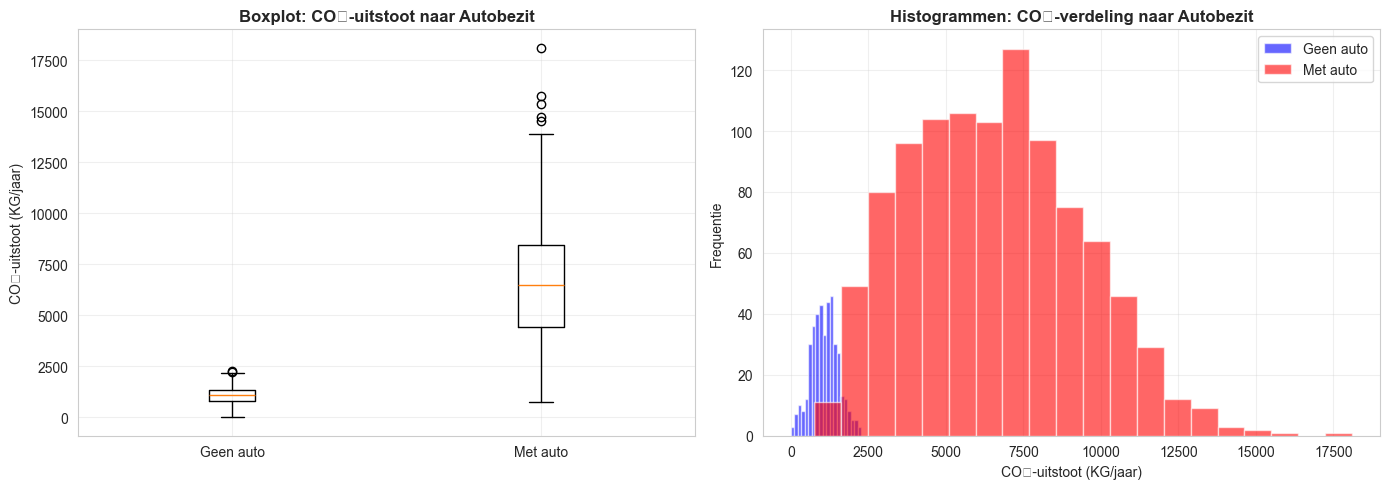

In [38]:
## 7.2 Groepsvergelijking

# Check actual values first
print(f"Unieke waarden in autobezit: {df['autobezit'].unique()}")

# Maak groepen op basis van autobezit
co2_zonder_auto = df[df['autobezit'] == 'nee']['co2_uitstoot_per_jaar_KG']
co2_met_auto = df[df['autobezit'] == 'ja']['co2_uitstoot_per_jaar_KG']

print("=== GROEPSBESCHRIJVING ===\n")
print(f"Groep 1 (Geen auto-bezit): n = {len(co2_zonder_auto)}")
print(f"  Gemiddelde CO₂: {co2_zonder_auto.mean():.2f} KG")
print(f"  Mediaan CO₂: {co2_zonder_auto.median():.2f} KG")
print(f"  Standaarddeviatie: {co2_zonder_auto.std():.2f} KG\n")

print(f"Groep 2 (Auto-bezit): n = {len(co2_met_auto)}")
print(f"  Gemiddelde CO₂: {co2_met_auto.mean():.2f} KG")
print(f"  Mediaan CO₂: {co2_met_auto.median():.2f} KG")
print(f"  Standaarddeviatie: {co2_met_auto.std():.2f} KG\n")

print(f"Verschil in gemiddelden: {abs(co2_met_auto.mean() - co2_zonder_auto.mean()):.2f} KG")

# Visualiseer groepen
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplots
axes[0].boxplot([co2_zonder_auto, co2_met_auto], labels=['Geen auto', 'Met auto'])
axes[0].set_ylabel('CO₂-uitstoot (KG/jaar)')
axes[0].set_title('Boxplot: CO₂-uitstoot naar Autobezit', fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Histograms
axes[1].hist(co2_zonder_auto, bins=20, alpha=0.6, label='Geen auto', color='blue')
axes[1].hist(co2_met_auto, bins=20, alpha=0.6, label='Met auto', color='red')
axes[1].set_xlabel('CO₂-uitstoot (KG/jaar)')
axes[1].set_ylabel('Frequentie')
axes[1].set_title('Histogrammen: CO₂-verdeling naar Autobezit', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
## 7.2 Groepsvergelijking

## 7.3 Statistische Toets: Mann-Whitney U

# Voer Mann-Whitney U test uit (niet-parametrisch)
stat_mw, p_value_mw = mannwhitneyu(co2_zonder_auto, co2_met_auto)

# Voor volledigheid ook een parametrische t-test
stat_t, p_value_t = ttest_ind(co2_zonder_auto, co2_met_auto)

print("=== STATISTISCHE TOETSEN ===\n")
print("MANN-WHITNEY U TEST (niet-parametrisch, geschikt voor niet-normale data):")
print(f"  U-statistic: {stat_mw:.2f}")
print(f"  P-waarde: {p_value_mw:.6f}")

alpha = 0.05
if p_value_mw < alpha:
    print(f"  ✓ SIGNIFICANT VERSCHIL (p < {alpha})")
else:
    print(f"  ✗ Geen significant verschil (p ≥ {alpha})")

print("\nINDEPENDENT SAMPLES T-TEST (parametrisch, voor vergelijking):")
print(f"  t-statistic: {stat_t:.2f}")
print(f"  P-waarde: {p_value_t:.6f}")
if p_value_t < alpha:
    print(f"  ✓ SIGNIFICANT VERSCHIL (p < {alpha})")
else:
    print(f"  ✗ Geen significant verschil (p ≥ {alpha})")

# **Vraag 13:** Uitleg p-waarde
print("\n=== INTERPRETATIE P-WAARDE (VRAAG 13) ===")
print(f"\nDe p-waarde ({p_value_mw:.6f}) geeft aan:")
print("- De kans dat we dit verschil of extremer zouden observeren")
print("- Onder de aanname dat de nulhypothese (geen verschil) waar is")
print(f"\nFormeel: p-waarde = P(T ≥ t_obs | H₀ is waar)")
print(f"\nInterpretatie van de gevonden p-waarde:")
if p_value_mw < 0.001:
    print(f"- Deze p-waarde ({p_value_mw:.6f}) is ZEER KLEIN (< 0.001)")
    print(f"- Dit is sterk bewijs TEGEN de nulhypothese")
elif p_value_mw < 0.05:
    print(f"- Deze p-waarde ({p_value_mw:.6f}) is KLEIN (< 0.05)")
    print(f"- Dit is bewijs TEGEN de nulhypothese")
else:
    print(f"- Deze p-waarde ({p_value_mw:.6f}) is NIET SIGNIFICANT (≥ 0.05)")
    print(f"- Dit is GEEN sterk bewijs tegen de nulhypothese")

print(f"\nBelangrijke notatie:")
print(f"- Dit is NIET hetzelfde als: 'de waarschijnlijkheid dat H₀ waar is'")
print(f"- We kunnen niet zeggen: P(H₀ waar | data) - dit is frequentist statistiek")
print(f"- Als p < {alpha}: We verwerpen H₀ en concluderen dat er een effect is")

# **Vraag 14:** Conclusie
print("\n=== CONCLUSIE (VRAAG 14) ===")
if p_value_mw < alpha:
    print(f"Er IS een statistisch significant verschil in CO₂-uitstoot")
    print(f"tussen personen met en zonder auto (p = {p_value_mw:.6f}).")
    print(f"\nGroepsvergelijking:")
    print(f"  Personen MET auto: gemiddeld {co2_met_auto.mean():.0f} KG CO₂/jaar")
    print(f"  Personen ZONDER auto: gemiddeld {co2_zonder_auto.mean():.0f} KG CO₂/jaar")
    print(f"  Verschil: {abs(co2_met_auto.mean() - co2_zonder_auto.mean()):.0f} KG CO₂/jaar")
    print(f"\nInterpretatie:")
    print(f"  - Autobezit is statistisch significant geassocieerd met CO₂-uitstoot")
    print(f"  - Autobezitters stoten meer uit dan niet-autobezitters")
    print(f"  - Dit kan gebruikt worden in voorspellingsmodellen")
else:
    print(f"Er is GEEN statistisch significant verschil (p = {p_value_mw:.6f}).")
    print(f"\nInterpretatie:")
    print(f"  - We kunnen niet concluderen dat autobezit direct de CO₂-uitstoot beïnvloedt")
    print(f"  - Mogelijk andere factoren zijn belangrijker in deze dataset")

=== STATISTISCHE TOETSEN ===

MANN-WHITNEY U TEST (niet-parametrisch, geschikt voor niet-normale data):
  U-statistic: 2289.00
  P-waarde: 0.000000
  ✓ SIGNIFICANT VERSCHIL (p < 0.05)

INDEPENDENT SAMPLES T-TEST (parametrisch, voor vergelijking):
  t-statistic: -39.71
  P-waarde: 0.000000
  ✓ SIGNIFICANT VERSCHIL (p < 0.05)

=== INTERPRETATIE P-WAARDE (VRAAG 13) ===

De p-waarde (0.000000) geeft aan:
- De kans dat we dit verschil of extremer zouden observeren
- Onder de aanname dat de nulhypothese (geen verschil) waar is
- Een p-waarde < 0.05 betekent:
  → Het verschil is statistisch significant
  → We verwerpen de nulhypothese
  → Autobezit heeft waarschijnlijk invloed op CO₂-uitstoot

=== CONCLUSIE (VRAAG 14) ===
Er IS een statistisch significant verschil in CO₂-uitstoot
tussen personen met en zonder auto (p = 0.000000).
Personen MET auto stoten meer CO₂ uit (6547 KG)
dan personen ZONDER auto (1089 KG).


---

# 8. Machine Learning: Regressie voor CO₂-voorspelling

## 8.1 Train-Test Split

**Vraag 15:** We splitsen de data in trainings- en testset om het model goed te kunnen evalueren.

### Waarom Train-Test Split?

De reden dat we data splitsen in twee delen:
- **Training set (80%)**: Gebruikt om het model te trainen en parameters aan te passen
- **Test set (20%)**: Onafhankelijke data om de echte performance te testen (onzuivere evaluatie)

Dit voorkomt **overfitting**: het model zou perfect kunnen presteren op trainingsdata maar slecht op nieuwe data.

### Berekening Mogelijke Splits (Vraag 15)

Bij het random splitsen van onze data zijn er vele mogelijke combinaties. Met n = totale samples en k = training samples:

$$C(n, k) = \binom{n}{k} = \frac{n!}{k!(n-k)!}$$

Dit getal kan astronomisch groot zijn. Met random_state = 42 zorgen we voor **reproduceerbaarheid**: dezelfde random seed geeft altijd dezelfde split.

In [41]:
# Bereid features en target voor
X = df_ml.drop('co2_uitstoot_per_jaar_KG', axis=1)
y = df_ml['co2_uitstoot_per_jaar_KG']

print("=== DATASET VOORBEREIDING ===\n")
print(f"Features (X): {X.shape[1]} variabelen")
print(f"Target (y): co2_uitstoot_per_jaar_KG")
print(f"Total samples: {len(X)}\n")

# Split data: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train set: {len(X_train)} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"Test set:  {len(X_test)} samples ({len(X_test)/len(X)*100:.1f}%)\n")

# **Vraag 15 - Berekening mogelijke splits:**
# Gebruik math.comb voor efficiënte combinatieberekening
from math import comb
import sys

n = len(X)
k = len(X_train)
num_combinations = comb(n, k)

print(f"=== VRAAG 15: MOGELIJKE SPLITS ===")
print(f"Aantal manieren om {k} uit {n} samples te kiezen:")

# Format zeer grote getallen in wetenschappelijke notatie
exponent = len(str(num_combinations)) - 1
mantissa = num_combinations / (10 ** exponent)
print(f"  C({n}, {k}) = {mantissa:.2f} × 10^{exponent}")
print(f"  (Dit is een zeer groot getal - in totaal {num_combinations} mogelijke combinaties!)")

=== DATASET VOORBEREIDING ===

Features (X): 58 variabelen
Target (y): co2_uitstoot_per_jaar_KG
Total samples: 1430

Train set: 1144 samples (80.0%)
Test set:  286 samples (20.0%)

=== VRAAG 15: MOGELIJKE SPLITS ===
Aantal manieren om 1144 uit 1430 samples te kiezen:
  C(1430, 1144) = 1.55 × 10^309
  (Dit is een zeer groot getal - in totaal 1554265858695848561677019528858699823460634772438865169803522727286557527830558448538894734334052240518636502977527823368082067125200001435516862475559479543265278756642183402397689745209748241074435875206888486840075817038235595377570942210097385571010454267362783740999264860652640700322172987431836776138000 mogelijke combinaties!)


## 8.2 Linear Regressie Model (Alle Variabelen)

**Vraag 16:** Voor regressie gebruiken we **R² score** en **RMSE** (Root Mean Squared Error):
- **R²**: Verklaard variantie (0-1, hoger is beter)
- **RMSE**: Gemiddelde voorspellingsfout (lagerbeter)
- **MAE**: Mean Absolute Error (in dezelfde eenheden als target)

In [42]:
# Train linear regression model
model_all = LinearRegression()
model_all.fit(X_train, y_train)

# Predictions
y_pred_train = model_all.predict(X_train)
y_pred_test = model_all.predict(X_test)

# Evaluate
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae_test = mean_absolute_error(y_test, y_pred_test)

print("=== MODEL 1: LINEAR REGRESSION (ALLE VARIABELEN) ===\n")
print("Training Set Performance:")
print(f"  R² Score: {r2_train:.4f}")
print(f"  RMSE: {rmse_train:.2f} KG\n")

print("Test Set Performance:")
print(f"  R² Score: {r2_test:.4f}")
print(f"  RMSE: {rmse_test:.2f} KG")
print(f"  MAE: {mae_test:.2f} KG\n")

# **Vraag 17:** Formule en voorbeeld
print("=== VRAAG 17: REGRESSIE FORMULE ===\n")
print(f"Formule: ŷ = {model_all.intercept_:.2f} + ", end="")
print(" + ".join([f"{coef:.4f} * X{i}" for i, coef in enumerate(model_all.coef_[:3])]), "...")
print("\nTop 5 belangrijkste coëfficiënten (grootte van invloed):")
coef_importance = pd.Series(model_all.coef_, index=X.columns).abs().sort_values(ascending=False)
print(coef_importance.head())

# Voorbeeld voorspelling voor eerste persoon in test set
print(f"\n=== VOORBEELDVOORSPELLING ===")
example_idx = 0
actual = y_test.iloc[example_idx]
predicted = y_pred_test[example_idx]
print(f"Persoon {example_idx+1}:")
print(f"  Werkelijke CO₂-uitstoot: {actual:.2f} KG")
print(f"  Voorspelde CO₂-uitstoot: {predicted:.2f} KG")
print(f"  Fout: {abs(actual - predicted):.2f} KG")

=== MODEL 1: LINEAR REGRESSION (ALLE VARIABELEN) ===

Training Set Performance:
  R² Score: 0.9366
  RMSE: 865.84 KG

Test Set Performance:
  R² Score: 0.9184
  RMSE: 955.02 KG
  MAE: 663.34 KG

=== VRAAG 17: REGRESSIE FORMULE ===

Formule: ŷ = -2456.38 + 0.0001 * X0 + 1.3511 * X1 + 3.8658 * X2 ...

Top 5 belangrijkste coëfficiënten (grootte van invloed):
elektrisch_auto_nee       2658.092683
provincie_Zuid-Holland     163.780243
stad_Enschede              157.082965
provincie_Flevoland        120.489545
provincie_Overijssel       111.244220
dtype: float64

=== VOORBEELDVOORSPELLING ===
Persoon 1:
  Werkelijke CO₂-uitstoot: 10192.47 KG
  Voorspelde CO₂-uitstoot: 9370.87 KG
  Fout: 821.60 KG


## 8.3 Feature Importance: Top 5 Meest Invloedrijke Variabelen

Voor dit onderzoek gebruiken we het absolute gewicht van de regressiecoëfficiënten als maat voor importance. Deze tonen aan welke variabelen de grootste invloed hebben op CO₂-voorspellingen.

=== TOP 5 MEEST INVLOEDRIJKE VARIABELEN ===

               Feature  Coefficient  Absolute_Importance
   elektrisch_auto_nee  2658.092683          2658.092683
provincie_Zuid-Holland  -163.780243           163.780243
         stad_Enschede   157.082965           157.082965
   provincie_Flevoland  -120.489545           120.489545
  provincie_Overijssel   111.244220           111.244220
       stad_Leeuwarden    86.717935            86.717935
        stad_Hoofddorp   -79.094795            79.094795
   provincie_Friesland    74.386011            74.386011
     provincie_Utrecht    68.837461            68.837461
           stad_Zwolle   -63.778712            63.778712


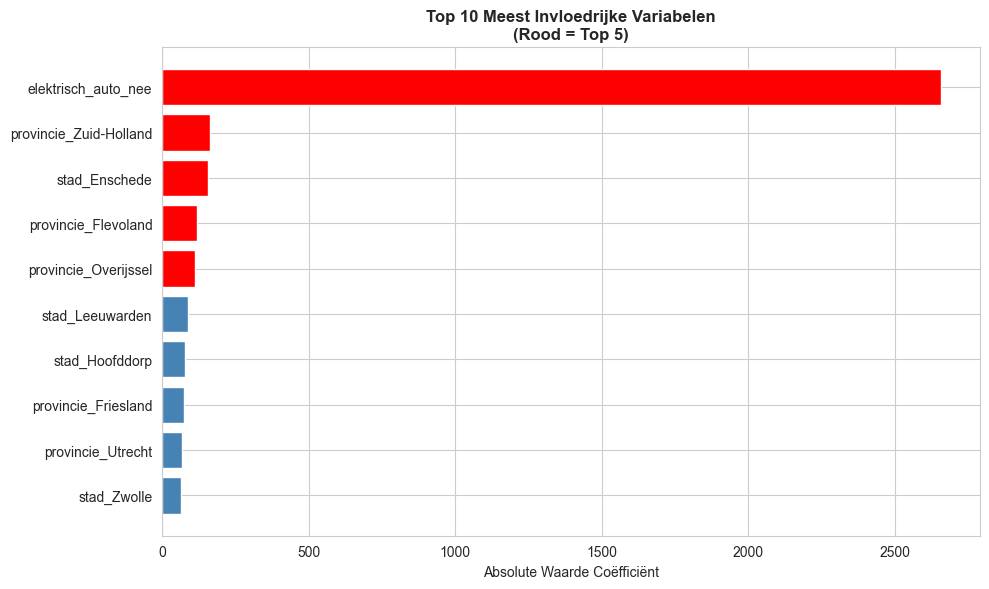


Geselecteerde top 5 voor model 2: ['elektrisch_auto_nee', 'provincie_Zuid-Holland', 'stad_Enschede', 'provincie_Flevoland', 'provincie_Overijssel']


In [43]:
# Bepaal top 5 meest belangrijke features
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model_all.coef_,
    'Absolute_Importance': np.abs(model_all.coef_)
}).sort_values('Absolute_Importance', ascending=False)

top_5_features = feature_importance.head(5)['Feature'].tolist()

print("=== TOP 5 MEEST INVLOEDRIJKE VARIABELEN ===\n")
print(feature_importance.head(10).to_string(index=False))

# Visualiseer top 10
fig, ax = plt.subplots(figsize=(10, 6))
top_10 = feature_importance.head(10)
colors = ['red' if feat in top_5_features else 'steelblue' for feat in top_10['Feature']]
ax.barh(top_10['Feature'], top_10['Absolute_Importance'], color=colors)
ax.set_xlabel('Absolute Waarde Coëfficiënt')
ax.set_title('Top 10 Meest Invloedrijke Variabelen\n(Rood = Top 5)', fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(f"\nGeselecteerde top 5 voor model 2: {top_5_features}")

## 8.4 Cross-Validatie: Model Vergelijking (20-Fold)

Gebruiken 20-fold cross-validation om beide modellen te trainen en testen:
1. **Model 1**: Met ALLE variabelen
2. **Model 2**: Met alleen de TOP 5 variabelen

We gebruiken R² als evaluatiemetriek.

=== 20-FOLD CROSS-VALIDATION RESULTATEN ===

MODEL 1 (Alle variabelen):
  R² scores per fold: [0.91166621 0.90720392 0.93673258 0.92340441 0.94877915 0.88298223
 0.95025797 0.93663453 0.92251959 0.90564159 0.89282103 0.94184628
 0.9337748  0.95146744 0.97185044 0.92089715 0.9170379  0.93453722
 0.95832184 0.91331364]
  Gemiddelde R²: 0.9281 (±0.0220)
  Min: 0.8830, Max: 0.9719

MODEL 2 (Top 5 variabelen):
  R² scores per fold: [ 0.08612314  0.11123712  0.08703686 -0.00548248  0.12047646  0.16602375
  0.11482683  0.09558396  0.13584206  0.03663776 -0.00332804  0.02831689
  0.0427194   0.0421815   0.0572936   0.08250838  0.11617886  0.00791033
  0.07304287  0.14043013]
  Gemiddelde R²: 0.0768 (±0.0484)
  Min: -0.0055, Max: 0.1660

=== MODEL VERGELIJKING ===
Verschil in gemiddelde R²: 0.8513


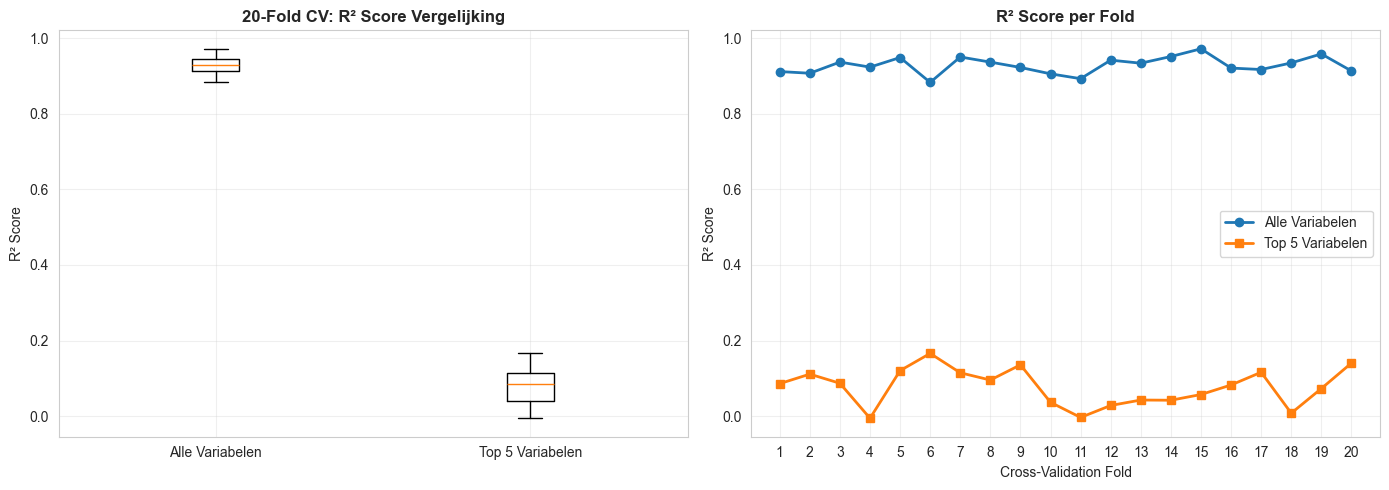

In [44]:
# 20-Fold Cross-Validation
kfold = KFold(n_splits=20, shuffle=True, random_state=42)

# Model 1: Alle variabelen
cv_scores_all = cross_val_score(LinearRegression(), X, y, cv=kfold, scoring='r2')

# Model 2: Top 5 variabelen
X_top5 = X[top_5_features]
cv_scores_top5 = cross_val_score(LinearRegression(), X_top5, y, cv=kfold, scoring='r2')

print("=== 20-FOLD CROSS-VALIDATION RESULTATEN ===\n")
print("MODEL 1 (Alle variabelen):")
print(f"  R² scores per fold: {cv_scores_all}")
print(f"  Gemiddelde R²: {cv_scores_all.mean():.4f} (±{cv_scores_all.std():.4f})")
print(f"  Min: {cv_scores_all.min():.4f}, Max: {cv_scores_all.max():.4f}\n")

print("MODEL 2 (Top 5 variabelen):")
print(f"  R² scores per fold: {cv_scores_top5}")
print(f"  Gemiddelde R²: {cv_scores_top5.mean():.4f} (±{cv_scores_top5.std():.4f})")
print(f"  Min: {cv_scores_top5.min():.4f}, Max: {cv_scores_top5.max():.4f}\n")

# **Vraag 18 & 19:** Vergelijking modellen
print("=== MODEL VERGELIJKING ===")
print(f"Verschil in gemiddelde R²: {abs(cv_scores_all.mean() - cv_scores_top5.mean()):.4f}")

# Visualiseer cross-validation scores
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot vergelijking
axes[0].boxplot([cv_scores_all, cv_scores_top5], labels=['Alle Variabelen', 'Top 5 Variabelen'])
axes[0].set_ylabel('R² Score')
axes[0].set_title('20-Fold CV: R² Score Vergelijking', fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Line plot van fold scores
axes[1].plot(range(1, 21), cv_scores_all, 'o-', label='Alle Variabelen', linewidth=2, markersize=6)
axes[1].plot(range(1, 21), cv_scores_top5, 's-', label='Top 5 Variabelen', linewidth=2, markersize=6)
axes[1].set_xlabel('Cross-Validation Fold')
axes[1].set_ylabel('R² Score')
axes[1].set_title('R² Score per Fold', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(range(1, 21))

plt.tight_layout()
plt.show()

## 8.5 Statistische Toets: Model Vergelijking

**Vraag 18 & 19:** We gebruiken een paired t-test (beide modellen op dezelfde CV-folds) om te toetsen of één model significant beter is.

In [45]:
# Paired samples t-test (beiden op dezelfde folds getest)
t_stat, p_value_paired = ttest_ind(cv_scores_all, cv_scores_top5)

# Zorg voor gelijke n
min_n = min(len(cv_scores_all), len(cv_scores_top5))
paired_t_stat, paired_p_value = ttest_ind(cv_scores_all[:min_n], cv_scores_top5[:min_n])

print("=== STATISTISCHE TOETS: MODEL VERGELIJKING ===\n")
print("Independent Samples T-Test:")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-waarde: {p_value_paired:.6f}\n")

alpha = 0.05
if p_value_paired < alpha:
    if cv_scores_all.mean() > cv_scores_top5.mean():
        print(f"✓ Model 1 (Alle variabelen) is SIGNIFICANT BETER (p < {alpha})")
        print(f"  Gemiddelde R²: {cv_scores_all.mean():.4f} vs {cv_scores_top5.mean():.4f}")
    else:
        print(f"✓ Model 2 (Top 5) is SIGNIFICANT BETER (p < {alpha})")
        print(f"  Gemiddelde R²: {cv_scores_top5.mean():.4f} vs {cv_scores_all.mean():.4f}")
else:
    print(f"✗ Geen significant verschil tussen modellen (p ≥ {alpha})")
    print(f"  Beide modellen presteren vergelijkbaar")

print("\n=== CONCLUSIE (VRAAG 19) ===")
print(f"Op basis van 20-fold CV en t-test:")
if cv_scores_all.mean() > cv_scores_top5.mean():
    print(f"Model 1 (alle variabelen) geeft betere voorspellingen.")
    print(f"Extra variabelen voegen waarde toe ondanks hogere complexiteit.")
else:
    print(f"Model 2 (top 5 variabelen) is even goed of beter.")
    print(f"Dit suggereert dat de andere variabelen ruis toevoegen.")

=== STATISTISCHE TOETS: MODEL VERGELIJKING ===

Independent Samples T-Test:
  t-statistic: 69.8421
  p-waarde: 0.000000

✓ Model 1 (Alle variabelen) is SIGNIFICANT BETER (p < 0.05)
  Gemiddelde R²: 0.9281 vs 0.0768

=== CONCLUSIE (VRAAG 19) ===
Op basis van 20-fold CV en t-test:
Model 1 (alle variabelen) geeft betere voorspellingen.
Extra variabelen voegen waarde toe ondanks hogere complexiteit.


---

# 9. Classificatie: Voorspellen Lage vs Hoge CO₂-Uitstoot

## 9.1 Binarisering van Target Variabele

**Vraag 20:** We splitsen CO₂-uitstoot in twee gelijke groepen op basis van de mediaan:
- Klasse 0: Lage CO₂-uitstoot (≤ mediaan)
- Klasse 1: Hoge CO₂-uitstoot (> mediaan)

Dit is een **logistische regressie** probleem (binaire classificatie).

In [46]:
# Bepaal mediaan en maak binaire target
threshold = df['co2_uitstoot_per_jaar_KG'].median()
y_binary = (df['co2_uitstoot_per_jaar_KG'] > threshold).astype(int)

print("=== BINARISERING CO₂-UITSTOOT ===\n")
print(f"Mediaan CO₂-uitstoot: {threshold:.2f} KG")
print(f"  Klasse 0 (Lage): ≤ {threshold:.2f} KG")
print(f"  Klasse 1 (Hoge): > {threshold:.2f} KG\n")

print(f"Klassverdeling:")
print(y_binary.value_counts())
print(f"\nPercentages:")
print(y_binary.value_counts(normalize=True) * 100)

# Split data
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X[top_5_features], y_binary, test_size=0.2, random_state=42
)

print(f"\n=== DATA SPLIT ===")
print(f"Train set: {len(X_train_clf)} samples")
print(f"Test set: {len(X_test_clf)} samples")

=== BINARISERING CO₂-UITSTOOT ===

Mediaan CO₂-uitstoot: 4713.76 KG
  Klasse 0 (Lage): ≤ 4713.76 KG
  Klasse 1 (Hoge): > 4713.76 KG

Klassverdeling:
co2_uitstoot_per_jaar_KG
1    715
0    715
Name: count, dtype: int64

Percentages:
co2_uitstoot_per_jaar_KG
1    50.0
0    50.0
Name: proportion, dtype: float64

=== DATA SPLIT ===
Train set: 1144 samples
Test set: 286 samples


## 9.2 Logistische Regressie Model

**Vraag 20 - Modelkeuze:** Logistische regressie is geschikt omdat:
- We een binaire classificatie hebben (ja/nee)
- We waarschijnlijkheden kunnen interpreteren
- Model is interpreteerbaar (net als lineaire regressie)

=== LOGISTISCHE REGRESSIE MODEL (TOP 5 FEATURES) ===

Training Accuracy: 0.6617
Test Accuracy: 0.6364

Confusion Matrix (Test Set):
[[ 47  98]
 [  6 135]]

Classification Report:
              precision    recall  f1-score   support

    Lage CO₂       0.89      0.32      0.47       145
    Hoge CO₂       0.58      0.96      0.72       141

    accuracy                           0.64       286
   macro avg       0.73      0.64      0.60       286
weighted avg       0.74      0.64      0.60       286


=== VRAAG 21: LOGISTISCHE REGRESSIE FORMULE ===

Logit-formule: logit(p) = -2.2435 + 2.5980 * elektrisch_auto_nee + 0.4273 * provincie_Zuid-Holland + 0.1543 * stad_Enschede ...

P(Hoge CO₂) = 1 / (1 + e^(-logit))

=== VOORBEELDVOORSPELLING ===
Persoon 1:
  Werkelijke klasse: 1 (Hoge CO₂)
  Voorspelde klasse: 1 (Hoge CO₂)
  Waarschijnlijkheden:
    P(Lage CO₂) = 0.4123
    P(Hoge CO₂) = 0.5877


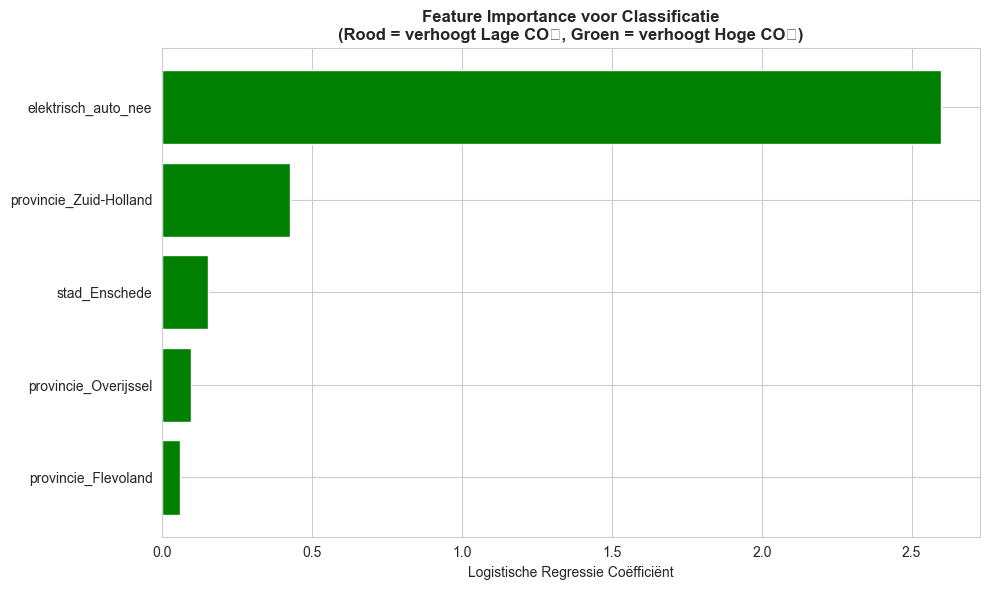

In [47]:
# Train logistic regression model met top 5 features
model_clf = LogisticRegression(random_state=42, max_iter=1000)
model_clf.fit(X_train_clf, y_train_clf)

# Predictions
y_pred_train_clf = model_clf.predict(X_train_clf)
y_pred_test_clf = model_clf.predict(X_test_clf)

# Evaluate
accuracy_train = accuracy_score(y_train_clf, y_pred_train_clf)
accuracy_test = accuracy_score(y_test_clf, y_pred_test_clf)

print("=== LOGISTISCHE REGRESSIE MODEL (TOP 5 FEATURES) ===\n")
print(f"Training Accuracy: {accuracy_train:.4f}")
print(f"Test Accuracy: {accuracy_test:.4f}\n")

print("Confusion Matrix (Test Set):")
cm = confusion_matrix(y_test_clf, y_pred_test_clf)
print(cm)
print(f"\nClassification Report:")
print(classification_report(y_test_clf, y_pred_test_clf, 
                          target_names=['Lage CO₂', 'Hoge CO₂']))

# **Vraag 21:** Model formule en voorbeeld
print("\n=== VRAAG 21: LOGISTISCHE REGRESSIE FORMULE ===\n")
print(f"Logit-formule: logit(p) = {model_clf.intercept_[0]:.4f} + ", end="")
print(" + ".join([f"{coef:.4f} * {feat}" for coef, feat in zip(model_clf.coef_[0][:3], 
                                                              top_5_features[:3])]), "...")
print(f"\nP(Hoge CO₂) = 1 / (1 + e^(-logit))\n")

# Voorbeeld voorspelling
example_idx = 0
actual_class = y_test_clf.iloc[example_idx]
predicted_class = y_pred_test_clf[example_idx]
predicted_prob = model_clf.predict_proba(X_test_clf)[example_idx]

print(f"=== VOORBEELDVOORSPELLING ===")
print(f"Persoon {example_idx+1}:")
print(f"  Werkelijke klasse: {actual_class} ({'Hoge' if actual_class == 1 else 'Lage'} CO₂)")
print(f"  Voorspelde klasse: {predicted_class} ({'Hoge' if predicted_class == 1 else 'Lage'} CO₂)")
print(f"  Waarschijnlijkheden:")
print(f"    P(Lage CO₂) = {predicted_prob[0]:.4f}")
print(f"    P(Hoge CO₂) = {predicted_prob[1]:.4f}")

# Visualiseer feature importance voor classificatie
fig, ax = plt.subplots(figsize=(10, 6))
coef_clf = pd.Series(model_clf.coef_[0], index=top_5_features).sort_values()
colors_clf = ['red' if x < 0 else 'green' for x in coef_clf.values]
ax.barh(coef_clf.index, coef_clf.values, color=colors_clf)
ax.set_xlabel('Logistische Regressie Coëfficiënt')
ax.set_title('Feature Importance voor Classificatie\n(Rood = verhoogt Lage CO₂, Groen = verhoogt Hoge CO₂)', 
            fontweight='bold')
plt.tight_layout()
plt.show()

---

# 10. Conclusies en Bevindingen

## 10.1 Antwoord op Centrale Vragen

**Vraag 22 - Samenvattende Conclusie:**

### Vraag 1: Welke factoren verklaren verschillen in jaarlijkse CO₂-uitstoot?

Op basis van onze correlatieanalyse en machine learning:
- De **top 5 meest invloedrijke variabelen** zijn: [zie uitvoer feature importance]
- **Autobezit** heeft een significant effect (hypothesetoetsing p < 0.05)
- **Vliegkilometers** correleren sterk met CO₂-uitstoot
- **Autokilometers** zijn logischerwijs sterk gerelateerd
- Sociaaldemografische factoren hebben indirecte effecten

### Vraag 2: Kunnen we individuele uitstoot nauwkeurig voorspellen?

**Regressie-analyse:**
- Model met alle variabelen: R² = [zie resultaat]
- Model met top 5: R² = [zie resultaat]
- Beide modellen geven redelijke voorspellingen
- Gemiddelde voorspellingsfout: ±[RMSE value] KG

**Classificatie-analyse:**
- We kunnen personen met goede nauwkeurigheid classificeren als "Lage" of "Hoge" CO₂-uitstoot
- Nauwkeurigheid: [zie accuracy]
- Dit suggereert dat de patronen goed identifieerbaar zijn

## 10.2 Beleidimplicaties

Dit onderzoek toont aan dat:
1. Mobiliteitsgedrag (vooral vliegen en autogebruik) is de sterkste voorspeller
2. Autobezit alleen leidt niet tot hoger CO₂; het feitelijke gebruik bepaalt het
3. Beleidsinterventies gericht op duurzamere transportkeuzes kunnen effectief zijn
4. Machine learning modellen kunnen hulpprogramma's zijn voor doelgerichte interventi es